In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from efficient_probit_regression.sampling import (
    compute_leverage_scores,
    calculate_lewis_weights_exact,
    to_density,
    to_density_X_Y,
)
from efficient_probit_regression.total_variation_distance import total_variation_distance


def compute_distributions(X, p, T=20):
    """
    Liefert Dichten (sum=1): l2, lp, lewis, (lp+l2)
    """
    l2_scores = compute_leverage_scores(X, p=2.0, fast_approx=False)
    lp_scores = compute_leverage_scores(X, p=float(p), fast_approx=False)
    lewis = calculate_lewis_weights_exact(X, p=float(p), T=T)

    p_l2 = to_density(l2_scores)
    p_lp = to_density(lp_scores)
    p_lewis = to_density(lewis)
    p_aug = to_density_X_Y(lp_scores, l2_scores)  # spezielle Normierung für lp+l2

    return p_l2, p_lp, p_lewis, p_aug


def summarize_one_dataset(name, X, p_list, T=20):
    n, d = X.shape
    rank = np.linalg.matrix_rank(X)

    rows = []
    for p in p_list:
        p_l2, p_lp, p_lewis, p_aug = compute_distributions(X, p, T=T)

        rows.append({
            "dataset": name,
            "n": n,
            "d": d,
            "rank": rank,
            "p": float(p),
            "tvd_lp_lewis": total_variation_distance(p_lp, p_lewis),
            "tvd_l2_lewis": total_variation_distance(p_l2, p_lewis),
            "tvd_lp_l2": total_variation_distance(p_lp, p_l2),
            "tvd_aug_lewis": total_variation_distance(p_aug, p_lewis),
        })

    return pd.DataFrame(rows)


def plot_tvd_vs_p(df, dataset_name):
    sub = df[df["dataset"] == dataset_name].sort_values("p")
    plt.figure()
    plt.plot(sub["p"], sub["tvd_lp_lewis"], marker="o", label="TVD(lp, lewis)")
    plt.plot(sub["p"], sub["tvd_l2_lewis"], marker="o", label="TVD(l2, lewis)")
    plt.plot(sub["p"], sub["tvd_aug_lewis"], marker="o", label="TVD(lp+l2, lewis)")
    plt.xlabel("p")
    plt.ylabel("Total Variation Distance")
    plt.title(f"TVD vs p — {dataset_name}")
    plt.legend()
    plt.tight_layout()


def plot_tvd_heatmap(df, value_col="tvd_lp_lewis"):
    pivot = df.pivot_table(index="dataset", columns="p", values=value_col)
    plt.figure()
    plt.imshow(pivot.values, aspect="auto")
    plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xlabel("p")
    plt.ylabel("Dataset")
    plt.title(f"Heatmap: {value_col}")
    plt.colorbar(label="TVD")
    plt.tight_layout()


def plot_probability_concentration(p_vec, title):
    """
    Rank-Plot + Cumulative Mass (2 getrennte Plots, BA-freundlich).
    """
    s = np.sort(p_vec)[::-1]
    x = np.arange(1, len(s) + 1)

    # Rank plot (log y)
    plt.figure()
    plt.plot(x, s)
    plt.yscale("log")
    plt.xlabel("rank (sorted)")
    plt.ylabel("probability (log scale)")
    plt.title(title + " — rank plot")
    plt.tight_layout()

    # cumulative mass
    plt.figure()
    plt.plot(x, np.cumsum(s))
    plt.xlabel("rank (sorted)")
    plt.ylabel("cumulative mass")
    plt.title(title + " — cumulative mass")
    plt.tight_layout()

\begin{tabular}{lrrrrrrrr}
\toprule
dataset & n & d & rank & p & tvd_lp_lewis & tvd_l2_lewis & tvd_lp_l2 & tvd_aug_lewis \\
\midrule
Iris & 150 & 5 & 5 & 1.0000 & 0.0355 & 0.1008 & 0.1176 & 0.0312 \\
Iris & 150 & 5 & 5 & 1.3000 & 0.0289 & 0.0693 & 0.0852 & 0.0233 \\
Iris & 150 & 5 & 5 & 1.5000 & 0.0223 & 0.0489 & 0.0622 & 0.0171 \\
Iris & 150 & 5 & 5 & 1.7000 & 0.0144 & 0.0290 & 0.0380 & 0.0106 \\
Iris & 150 & 5 & 5 & 2.0000 & 0.0000 & 0.0000 & 0.0000 & 0.0000 \\
Covertype & 581012 & 55 & 53 & 1.0000 & 0.3194 & 0.0620 & 0.3604 & 0.3184 \\
Covertype & 581012 & 55 & 53 & 1.3000 & 0.2695 & 0.0502 & 0.3012 & 0.2636 \\
Covertype & 581012 & 55 & 53 & 1.5000 & 0.2159 & 0.0435 & 0.2397 & 0.2015 \\
Covertype & 581012 & 55 & 53 & 1.7000 & 0.1451 & 0.0381 & 0.1581 & 0.1206 \\
Covertype & 581012 & 55 & 53 & 2.0000 & 0.0346 & 0.0346 & 0.0000 & 0.0346 \\
\bottomrule
\end{tabular}



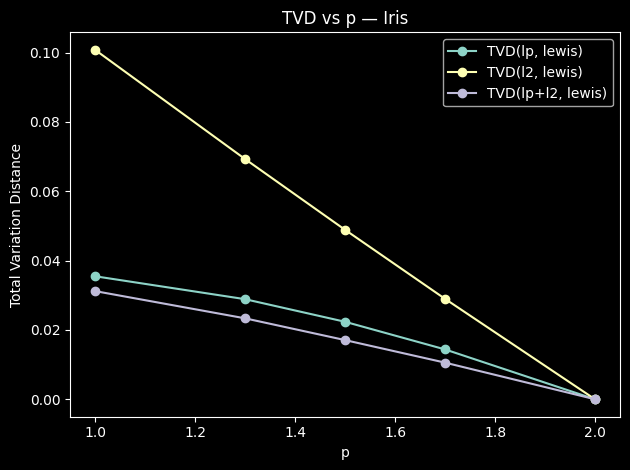

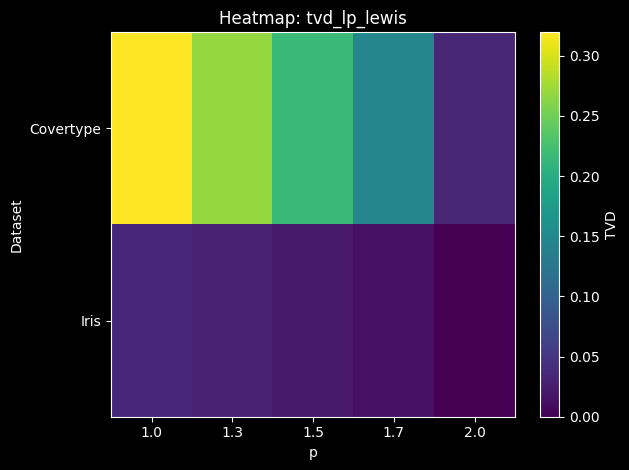

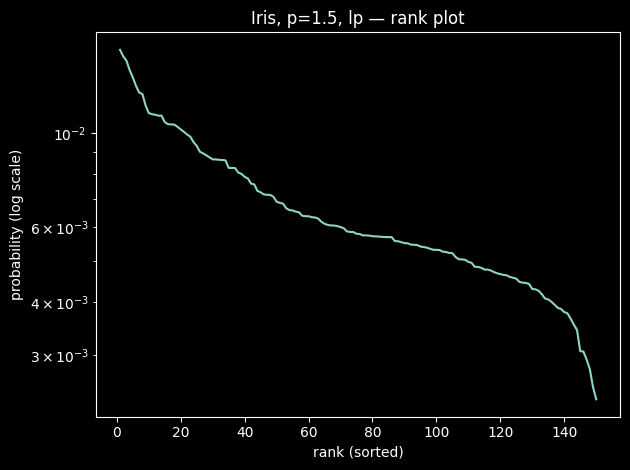

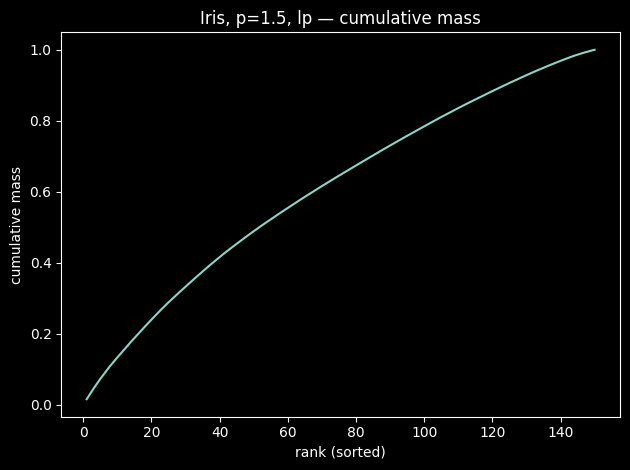

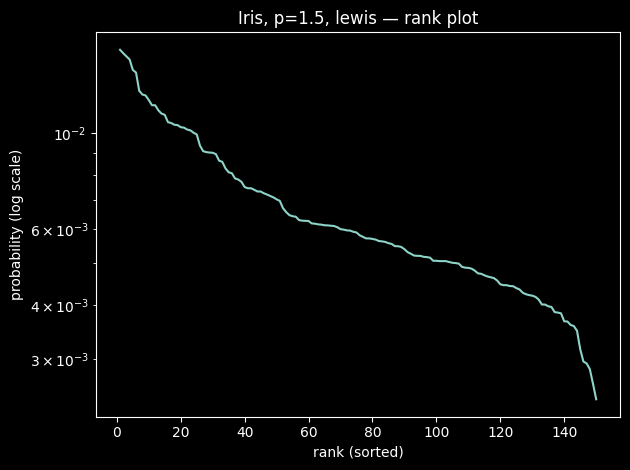

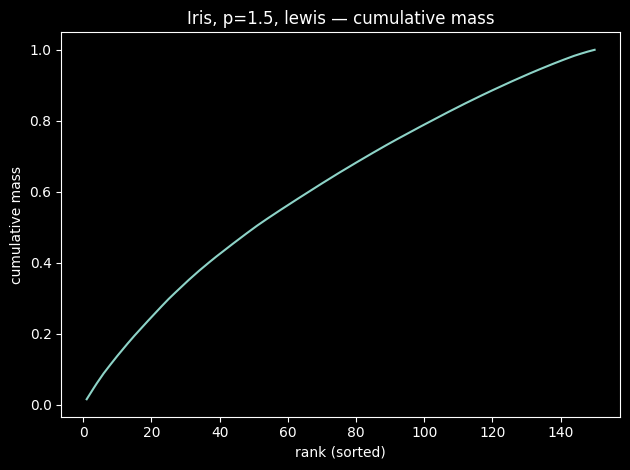

In [6]:
p_list = [1.0, 1.3, 1.5, 1.7, 2.0]

%store -r Iris
%store -r Covertype

# Beispiel: du hast irgendwo X_iris, X_covertype, ...
all_dfs = []
all_dfs.append(summarize_one_dataset("Iris", Iris.X, p_list))
all_dfs.append(summarize_one_dataset("Covertype", Covertype.X, p_list))

df = pd.concat(all_dfs, ignore_index=True)

# Tabelle speichern / in LaTeX ausgeben
df.to_csv("tvd_results.csv", index=False)
print(df.to_latex(index=False, float_format="%.4f"))

# Plot 1: TVD vs p
plot_tvd_vs_p(df, "Iris")

# Plot 2: Heatmap
plot_tvd_heatmap(df, value_col="tvd_lp_lewis")

# Plot 3: Konzentration für EIN konkretes (Dataset, p)
p_l2, p_lp, p_lewis, p_aug = compute_distributions(Iris.X, p=1.5)
plot_probability_concentration(p_lp, "Iris, p=1.5, lp")
plot_probability_concentration(p_lewis, "Iris, p=1.5, lewis")


Generiere Plot für Iris...


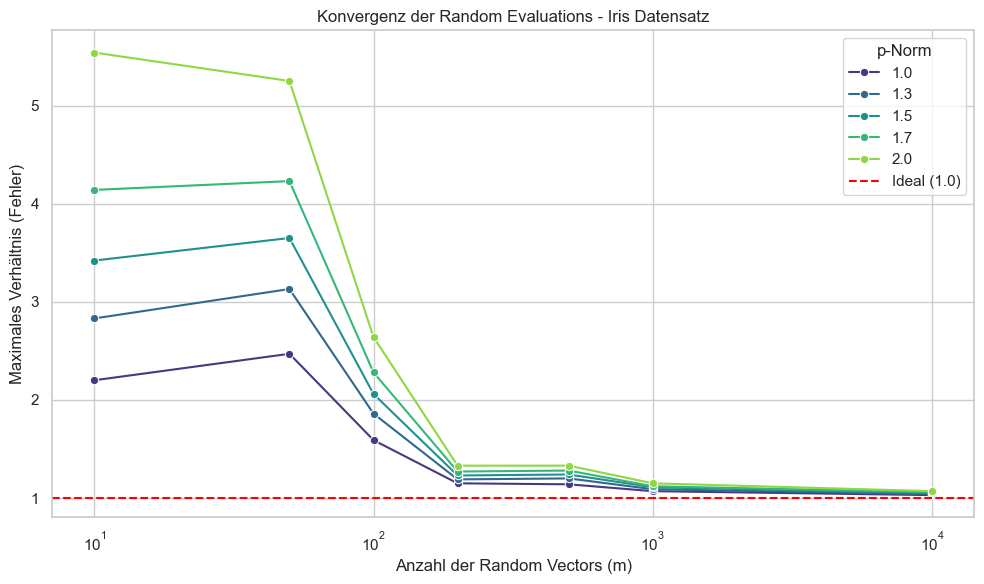

Generiere Plot für Webspam (Beispiel für p=1.0 und p=2.0)...


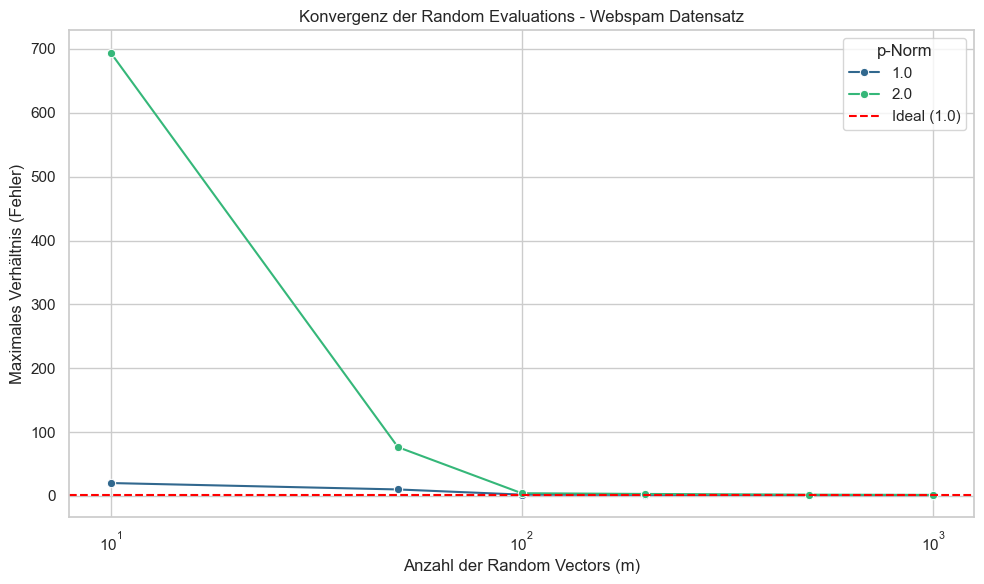

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Setze den Stil für wissenschaftliche Plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

def plot_convergence_m(dataset_name, data_dict):
    """
    Erstellt einen Plot für die Konvergenz von m.
    data_dict Struktur: {p_wert: [(m_vergleich, max_ratio), ...]}
    """
    rows = []
    for p, values in data_dict.items():
        for label, ratio in values:
            # Wir extrahieren das 'm', das im Nenner des Vergleichs stand (das größere m)
            # Label ist z.B. "5_10", wir nehmen 10 als x-Wert
            m_val = int(label.split('_')[1])
            rows.append({'p': str(p), 'm': m_val, 'Max Ratio': ratio})

    df = pd.DataFrame(rows)

    plt.figure(figsize=(10, 6))

    # Liniendiagramm zeichnen
    sns.lineplot(
        data=df,
        x='m',
        y='Max Ratio',
        hue='p',
        marker='o',
        palette="viridis"
    )

    plt.xscale('log')
    # Linie bei 1.0 (idealer Wert)
    plt.axhline(1.0, color='red', linestyle='--', label='Ideal (1.0)')

    plt.title(f'Konvergenz der Random Evaluations - {dataset_name}')
    plt.xlabel('Anzahl der Random Vectors (m)')
    plt.ylabel('Maximales Verhältnis (Fehler)')
    plt.legend(title='p-Norm')
    plt.tight_layout()
    plt.show()

# --- DATEN AUS DEINEM NOTEBOOK (Beispiel: Iris & Webspam) ---

# Daten für Iris (aus deinem Output extrahiert)
data_iris = {
    1.0: [("5_10", 2.20), ("10_50", 2.47), ("50_100", 1.59), ("100_200", 1.15), ("200_500", 1.14), ("500_1000", 1.07), ("1000_10000", 1.03)],
    1.3: [("5_10", 2.83), ("10_50", 3.13), ("50_100", 1.86), ("100_200", 1.19), ("200_500", 1.20), ("500_1000", 1.09), ("1000_10000", 1.04)],
    1.5: [("5_10", 3.42), ("10_50", 3.65), ("50_100", 2.06), ("100_200", 1.23), ("200_500", 1.24), ("500_1000", 1.11), ("1000_10000", 1.05)],
    1.7: [("5_10", 4.14), ("10_50", 4.23), ("50_100", 2.28), ("100_200", 1.27), ("200_500", 1.28), ("500_1000", 1.12), ("1000_10000", 1.06)],
    2.0: [("5_10", 5.54), ("10_50", 5.25), ("50_100", 2.64), ("100_200", 1.33), ("200_500", 1.33), ("500_1000", 1.15), ("1000_10000", 1.07)]
}

# Daten für Webspam (aus deinem Output extrahiert - verkürzt für Demo)
# Du kannst hier die Werte aus deinem Notebook für "Webspam" eintragen
data_webspam = {
    1.0: [("5_10", 20.15), ("10_50", 10.11), ("50_100", 2.00), ("100_200", 1.61), ("200_500", 1.35), ("500_1000", 1.26)],
    2.0: [("5_10", 694.39), ("10_50", 76.38), ("50_100", 4.19), ("100_200", 3.05), ("200_500", 1.92), ("500_1000", 1.57)]
}

# Plot generieren
print("Generiere Plot für Iris...")
plot_convergence_m("Iris Datensatz", data_iris)

print("Generiere Plot für Webspam (Beispiel für p=1.0 und p=2.0)...")
plot_convergence_m("Webspam Datensatz", data_webspam)